# General Pokemon Stats EDA

This notebook explores whether pre-battle Pokemon team stats contain useful signal for predicting battle outcome in Gen 9 random battles.

The main focus is on full-team Pokemon stats: HP, Attack, Defense, Special Attack, Special Defense, and Speed. For each battle, we compare the full six-Pokemon teams rather than only the Pokemon that appeared during the battle.

## Summary of Findings

| Topic | Finding | Interpretation |
|---|---|---|
| Full-team stat balance | Team mean stats are tightly centered across battles. | Random battle teams appear naturally balanced in aggregate stat profiles. |
| Winner vs loser stat comparison | Winning and losing teams have very similar full-team stat summaries. | Raw team stats alone may not explain much of the final battle outcome. |
| Full-team stats vs showed-up-only stats | Showed-up-only stats are affected by which Pokemon entered the battle. | These stats are post-battle information and can be biased by battle flow, early forfeits, disconnects, and outcome. |
| Early-ending battles | Some losing teams show only one or a few Pokemon because the player disconnected or forfeited early. | Low `n_appeared` should be treated as a data-quality or battle-process signal, not as a fair pre-battle team feature. |
| Modeling implication | Full-team stats are valid pre-battle features; showed-up-only stats are not. | For prediction, use full six-Pokemon team stats. Use showed-up-only stats only for diagnostic or descriptive analysis. |

## Conclusion

Full-team Pokemon stats appear balanced across random battle teams, and simple stat summaries do not strongly separate winners from losers. This suggests that raw stats alone are unlikely to be enough for strong prediction. More useful future features may need to describe team shape, speed tiers, Pokemon identity, type matchups, moves, abilities, or items.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


PROJECT_ROOT = Path(r"E:\Erdos\Project-Pokemon\summer26-pokemon-battle-predictor")
TOOLS_DIR = PROJECT_ROOT / "tools"
REPLAY_DIR = PROJECT_ROOT / "data" / "replays" / "gen9-randombattle"

if str(TOOLS_DIR) not in sys.path:
    sys.path.append(str(TOOLS_DIR))

from battle import Battle

In [2]:
STAT_NAMES = ["hp", "atk", "def", "spa", "spd", "spe"]

def summarize_stats(prefix, pokemon_infos):
    rows = {}

    if len(pokemon_infos) == 0:
        for stat in STAT_NAMES:
            rows[f"{prefix}_{stat}_mean"] = np.nan
            rows[f"{prefix}_{stat}_min"] = np.nan
            rows[f"{prefix}_{stat}_max"] = np.nan
        return rows

    stats_df = pd.DataFrame([info["stats"] for info in pokemon_infos])

    for stat in STAT_NAMES:
        rows[f"{prefix}_{stat}_mean"] = stats_df[stat].mean()
        rows[f"{prefix}_{stat}_min"] = stats_df[stat].min()
        rows[f"{prefix}_{stat}_max"] = stats_df[stat].max()

    return rows


def get_appeared_names(battle, side_idx):
    team = battle.teams[side_idx - 1]

    if team is None:
        return set()

    return set(team.keys())

In [3]:
battle_rows = []
player_team_rows = []
bad_files = []

for path in sorted(REPLAY_DIR.glob("*.json")):
    try:
        b = Battle(path)

        battle_row = {
            "battle_id": b.id,
            "file_name": path.name,
            "rated": b.rated,
            "rating": b.rating,
            "p1_elo0": b.p1.elo0,
            "p2_elo0": b.p2.elo0,
            "p1_elo1": b.p1.elo1,
            "p2_elo1": b.p2.elo1,
            "winner_side": b.winner.side,
            "p1_wins": b.winner.side == 1,
            "n_turns": len(b.TURNS) - 1,
            "duration_seconds": b.end_time - b.start_time,
        }

        for side_idx in [1, 2]:
            player = b.p1 if side_idx == 1 else b.p2
            team_full = b.teams_full[side_idx - 1]
            appeared_names = get_appeared_names(b, side_idx)

            full_team_names = sorted(team_full.keys())
            appeared_team_names = sorted(appeared_names)

            full_infos = list(team_full.values())
            appeared_infos = [
                info for name, info in team_full.items()
                if name in appeared_names
            ]

            side_prefix = f"p{side_idx}"

            battle_row[f"{side_prefix}_name"] = player.name
            battle_row[f"{side_prefix}_elo0"] = player.elo0
            battle_row[f"{side_prefix}_elo1"] = player.elo1
            battle_row[f"{side_prefix}_team"] = full_team_names
            battle_row[f"{side_prefix}_appeared_team"] = appeared_team_names
            battle_row[f"{side_prefix}_n_team"] = len(full_team_names)
            battle_row[f"{side_prefix}_n_appeared"] = len(appeared_team_names)

            for i, pokemon_name in enumerate(full_team_names, start=1):
                info = team_full[pokemon_name]
                stats = info["stats"]

                battle_row[f"{side_prefix}_mon_{i}"] = pokemon_name
                battle_row[f"{side_prefix}_mon_{i}_showed_up"] = pokemon_name in appeared_names

                for stat in STAT_NAMES:
                    battle_row[f"{side_prefix}_mon_{i}_{stat}"] = stats[stat]

            battle_row.update(
                summarize_stats(f"{side_prefix}_full_team", full_infos)
            )
            battle_row.update(
                summarize_stats(f"{side_prefix}_appeared_team", appeared_infos)
            )

            player_team_row = {
                "battle_id": b.id,
                "file_name": path.name,
                "side": side_idx,
                "player": player.name,
                "elo0": player.elo0,
                "elo1": player.elo1,
                "won": b.winner.side == side_idx,
                "n_turns": len(b.TURNS) - 1,
                "duration_seconds": b.end_time - b.start_time,
                "team": full_team_names,
                "appeared_team": appeared_team_names,
                "n_team": len(full_team_names),
                "n_appeared": len(appeared_team_names),
            }

            player_team_row.update(
                summarize_stats("full_team", full_infos)
            )
            player_team_row.update(
                summarize_stats("appeared_team", appeared_infos)
            )

            for i, pokemon_name in enumerate(full_team_names, start=1):
                info = team_full[pokemon_name]
                stats = info["stats"]

                player_team_row[f"mon_{i}"] = pokemon_name
                player_team_row[f"mon_{i}_showed_up"] = pokemon_name in appeared_names

                for stat in STAT_NAMES:
                    player_team_row[f"mon_{i}_{stat}"] = stats[stat]

            player_team_rows.append(player_team_row)

        battle_rows.append(battle_row)

    except Exception as e:
        bad_files.append({
            "file_name": path.name,
            "error_type": type(e).__name__,
            "error": str(e),
        })

battle_df = pd.DataFrame(battle_rows)
player_team_df = pd.DataFrame(player_team_rows)
bad_df = pd.DataFrame(bad_files)

battle_df.head()

,battle_id,file_name,rated,rating,p1_elo0,p2_elo0,p1_elo1,p2_elo1,winner_side,p1_wins,...,p2_appeared_team_def_max,p2_appeared_team_spa_mean,p2_appeared_team_spa_min,p2_appeared_team_spa_max,p2_appeared_team_spd_mean,p2_appeared_team_spd_min,p2_appeared_team_spd_max,p2_appeared_team_spe_mean,p2_appeared_team_spe_min,p2_appeared_team_spe_max
0,gen9randombattle-2631360263,gen9randombattle-2631360263.json,True,1772.0,1787,1837,1770,1854,2,False,...,227.0,168.833333,132.0,218.0,175.000000,137.0,228.0,162.333333,96.0,222.0
1,gen9randombattle-2631363920,gen9randombattle-2631363920.json,False,NaN,0,0,0,0,1,True,...,216.0,172.000000,117.0,222.0,159.500000,134.0,206.0,198.500000,117.0,255.0
2,gen9randombattle-2631365384,gen9randombattle-2631365384.json,True,1918.0,1895,1946,1918,1923,1,True,...,241.0,182.000000,137.0,241.0,200.666667,152.0,267.0,184.000000,103.0,251.0
3,gen9randombattle-2631366366,gen9randombattle-2631366366.json,True,1485.0,1506,1490,1485,1511,2,False,...,253.0,194.166667,125.0,252.0,199.666667,125.0,267.0,152.333333,117.0,210.0
4,gen9randombattle-2631366401,gen9randombattle-2631366401.json,True,1164.0,1188,1195,1164,1219,2,False,...,202.0,216.200000,143.0,273.0,187.000000,177.0,217.0,194.400000,131.0,270.0


In [4]:
player_team_df.head()

,battle_id,file_name,side,player,elo0,elo1,won,n_turns,duration_seconds,team,...,mon_5_spd,mon_5_spe,mon_6,mon_6_showed_up,mon_6_hp,mon_6_atk,mon_6_def,mon_6_spa,mon_6_spd,mon_6_spe
0,gen9randombattle-2631360263,gen9randombattle-2631360263.json,1,LaxMD,1787,1770,False,88,821,"[Delphox, Indeedee, Skarmory, Tauros, Victreeb...",...,177,177,Wugtrio,True,212,234,143,143,179,270
1,gen9randombattle-2631360263,gen9randombattle-2631360263.json,2,N.TdaRajada,1837,1854,True,88,821,"[Lokix, Mandibuzz, Mienshao, Snorlax, Torterra...",...,178,132,Wigglytuff,True,424,139,141,218,150,141
2,gen9randombattle-2631363920,gen9randombattle-2631363920.json,1,kaisarian,0,0,True,31,800,"[Ambipom, Breloom, Brute Bonnet, Mimikyu, Over...",...,154,187,Pincurchin,True,258,207,247,239,227,87
3,gen9randombattle-2631363920,gen9randombattle-2631363920.json,2,Flamesenpai557,0,0,False,31,800,"[Arceus, Breloom, Dugtrio, Gurdurr, Kilowattre...",...,147,255,Slaking,True,389,317,216,208,157,216
4,gen9randombattle-2631365384,gen9randombattle-2631365384.json,1,rgrgreger,1895,1918,True,32,324,"[Donphan, Electrode, Flareon, Latias, Primarin...",...,240,147,Sudowoodo,True,284,241,270,110,176,110


In [5]:
battle_df.describe()

,rating,p1_elo0,p2_elo0,p1_elo1,p2_elo1,winner_side,n_turns,duration_seconds,p1_n_team,p1_n_appeared,...,p2_appeared_team_def_max,p2_appeared_team_spa_mean,p2_appeared_team_spa_min,p2_appeared_team_spa_max,p2_appeared_team_spd_mean,p2_appeared_team_spd_min,p2_appeared_team_spd_max,p2_appeared_team_spe_mean,p2_appeared_team_spe_min,p2_appeared_team_spe_max
count,1460.000000,4798.000000,4798.000000,4798.000000,4798.000000,4798.000000,4798.000000,4798.000000,4798.0,4798.000000,...,4796.000000,4796.000000,4796.000000,4796.000000,4796.000000,4796.000000,4796.000000,4796.000000,4796.000000,4796.000000
mean,1558.193836,1826.265736,1838.694456,1826.716132,1839.079200,1.518758,23.658399,314.324927,6.0,5.177366,...,242.687239,190.540280,138.548165,242.901168,190.114380,150.437448,239.149917,180.861339,131.630734,228.225813
std,369.165521,448.114900,454.852101,447.551365,454.171009,0.499700,11.301164,167.942310,0.0,1.289303,...,43.598483,20.777328,26.663601,28.467185,19.041403,21.363326,38.398675,19.997923,29.114262,31.499224
min,1000.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,6.0,1.000000,...,125.000000,110.000000,88.000000,110.000000,114.500000,71.000000,125.000000,100.000000,57.000000,100.000000
25%,1239.750000,1859.750000,1875.250000,1862.500000,1870.000000,1.000000,17.000000,204.000000,6.0,5.000000,...,211.000000,177.237500,120.000000,227.000000,177.500000,139.000000,214.000000,168.000000,110.000000,211.000000
50%,1531.000000,1971.000000,1984.000000,1971.000000,1983.000000,2.000000,23.000000,291.000000,6.0,6.000000,...,236.000000,190.333333,135.000000,247.000000,188.333333,149.000000,236.000000,181.000000,129.000000,228.000000
75%,1909.000000,2063.000000,2079.000000,2064.000000,2079.750000,2.000000,29.000000,401.000000,6.0,6.000000,...,264.000000,204.500000,151.000000,259.000000,201.333333,161.000000,260.000000,193.500000,150.000000,241.000000
max,2402.000000,2506.000000,2546.000000,2506.000000,2546.000000,2.000000,121.000000,1994.000000,6.0,6.000000,...,383.000000,279.000000,279.000000,318.000000,325.000000,325.000000,402.000000,362.000000,362.000000,362.000000


In [6]:
player_team_df.describe()

,side,elo0,elo1,n_turns,duration_seconds,n_team,n_appeared,full_team_hp_mean,full_team_hp_min,full_team_hp_max,...,mon_5_def,mon_5_spa,mon_5_spd,mon_5_spe,mon_6_hp,mon_6_atk,mon_6_def,mon_6_spa,mon_6_spd,mon_6_spe
count,9596.000000,9596.000000,9596.000000,9596.000000,9596.000000,9596.0,9596.000000,9596.000000,9596.000000,9596.000000,...,9596.000000,9596.000000,9596.000000,9596.000000,9596.000000,9596.000000,9596.000000,9596.000000,9596.000000,9596.000000
mean,1.500000,1832.480096,1832.897666,23.658399,314.324927,6.0,5.160171,278.229436,238.064819,335.208003,...,191.876615,189.467382,190.489787,181.881096,278.055336,188.969675,189.651105,190.039079,187.694977,183.036057
std,0.500026,451.515311,450.892219,11.300575,167.933559,0.0,1.283511,16.812004,17.112142,56.429501,...,41.379815,46.995216,41.155481,42.980955,37.176457,52.538069,39.967827,45.076594,37.883313,42.594751
min,1.000000,0.000000,0.000000,1.000000,0.000000,6.0,1.000000,231.500000,191.000000,253.000000,...,117.000000,88.000000,88.000000,57.000000,212.000000,65.000000,120.000000,88.000000,88.000000,57.000000
25%,1.000000,1867.000000,1864.000000,17.000000,204.000000,6.0,5.000000,266.833333,225.000000,302.000000,...,164.000000,152.000000,164.000000,150.750000,257.000000,142.000000,159.000000,152.000000,162.000000,152.000000
50%,1.500000,1977.000000,1976.000000,23.000000,291.000000,6.0,6.000000,276.000000,240.000000,321.000000,...,185.000000,193.000000,182.000000,186.000000,271.000000,195.000000,185.000000,193.000000,179.000000,187.000000
75%,2.000000,2071.000000,2072.000000,29.000000,401.000000,6.0,6.000000,287.000000,249.000000,352.000000,...,215.000000,227.000000,215.000000,213.000000,292.000000,230.000000,211.000000,231.000000,208.000000,214.000000
max,2.000000,2546.000000,2546.000000,121.000000,1994.000000,6.0,6.000000,373.333333,302.000000,572.000000,...,380.000000,318.000000,402.000000,362.000000,435.000000,348.000000,380.000000,318.000000,402.000000,362.000000


In [7]:
def summarize_team_stats(team_full):
    stats_df = pd.DataFrame([mon_info["stats"] for mon_info in team_full.values()])

    out = {}
    for stat in STAT_NAMES:
        out[f"{stat}_mean"] = stats_df[stat].mean()
        out[f"{stat}_min"] = stats_df[stat].min()
        out[f"{stat}_max"] = stats_df[stat].max()

    out["bst_mean"] = stats_df[STAT_NAMES].sum(axis=1).mean()
    out["bst_min"] = stats_df[STAT_NAMES].sum(axis=1).min()
    out["bst_max"] = stats_df[STAT_NAMES].sum(axis=1).max()

    return out


team_rows = []
battle_rows = []
bad_files = []

for path in sorted(REPLAY_DIR.glob("*.json")):
    try:
        b = Battle(path)

        battle_row = {
            "battle_id": b.id,
            "file_name": path.name,
            "p1_wins": b.winner.side == 1,
            "winner_side": b.winner.side,
            "n_turns": len(b.TURNS) - 1,
        }

        for side_idx in [1, 2]:
            player = b.p1 if side_idx == 1 else b.p2
            team_full = b.teams_full[side_idx - 1]
            team_names = sorted(team_full.keys())
            stats_summary = summarize_team_stats(team_full)

            team_row = {
                "battle_id": b.id,
                "file_name": path.name,
                "side": side_idx,
                "player": player.name,
                "won": b.winner.side == side_idx,
                "team": team_names,
                "n_team": len(team_names),
            }
            team_row.update(stats_summary)
            team_rows.append(team_row)

            prefix = f"p{side_idx}"
            battle_row[f"{prefix}_team"] = team_names
            battle_row[f"{prefix}_n_team"] = len(team_names)

            for key, value in stats_summary.items():
                battle_row[f"{prefix}_{key}"] = value

        battle_rows.append(battle_row)

    except Exception as e:
        bad_files.append({
            "file_name": path.name,
            "error_type": type(e).__name__,
            "error": str(e),
        })

team_stats_df = pd.DataFrame(team_rows)
battle_stats_df = pd.DataFrame(battle_rows)
bad_df = pd.DataFrame(bad_files)

team_stats_df.head(), battle_stats_df.head(), bad_df.head()

(                     battle_id                         file_name  side  \
 0  gen9randombattle-2631360263  gen9randombattle-2631360263.json     1   
 1  gen9randombattle-2631360263  gen9randombattle-2631360263.json     2   
 2  gen9randombattle-2631363920  gen9randombattle-2631363920.json     1   
 3  gen9randombattle-2631363920  gen9randombattle-2631363920.json     2   
 4  gen9randombattle-2631365384  gen9randombattle-2631365384.json     1   
 
            player    won                                               team  \
 0           LaxMD  False  [Delphox, Indeedee, Skarmory, Tauros, Victreeb...   
 1     N.TdaRajada   True  [Lokix, Mandibuzz, Mienshao, Snorlax, Torterra...   
 2       kaisarian   True  [Ambipom, Breloom, Brute Bonnet, Mimikyu, Over...   
 3  Flamesenpai557  False  [Arceus, Breloom, Dugtrio, Gurdurr, Kilowattre...   
 4       rgrgreger   True  [Donphan, Electrode, Flareon, Latias, Primarin...   
 
    n_team     hp_mean  hp_min  hp_max  ...  spa_max    spd_mean  

In [8]:
summary_features = []

for stat in STAT_NAMES + ["bst"]:
    for agg in ["mean", "min", "max"]:
        feature = f"{stat}_{agg}"
        summary_features.append(feature)

        battle_stats_df[f"diff_{feature}"] = (
            battle_stats_df[f"p1_{feature}"] -
            battle_stats_df[f"p2_{feature}"]
        )

diff_features = [f"diff_{feature}" for feature in summary_features]
battle_stats_df[diff_features + ["p1_wins"]].head()

,diff_hp_mean,diff_hp_min,diff_hp_max,diff_atk_mean,diff_atk_min,diff_atk_max,diff_def_mean,diff_def_min,diff_def_max,diff_spa_mean,...,diff_spd_mean,diff_spd_min,diff_spd_max,diff_spe_mean,diff_spe_min,diff_spe_max,diff_bst_mean,diff_bst_min,diff_bst_max,p1_wins
0,-65.333333,-32,-134,-11.500000,-11,-15,13.666667,2,43,4.666667,...,13.333333,21,12,44.500000,62,48,-0.666667,-2,26,False
1,-13.333333,20,-80,0.333333,24,-54,12.500000,12,31,-7.500000,...,24.333333,13,21,-30.166667,-30,-14,-13.833333,38,-228,True
2,-12.500000,-1,-23,13.666667,-25,54,2.166667,22,29,9.000000,...,8.333333,-3,-16,-2.833333,7,60,17.833333,85,59,True
3,32.166667,14,52,38.000000,48,47,-4.500000,14,-20,-19.833333,...,-4.000000,28,-34,20.166667,-11,31,62.000000,33,224,False
4,-1.000000,34,-14,-62.000000,-119,-62,-5.333333,16,-36,14.333333,...,2.666667,-38,41,20.333333,68,-11,-31.000000,-11,-28,False


In [9]:
print("Team-level rows:", team_stats_df.shape)
print("Battle-level rows:", battle_stats_df.shape)
print("Bad files:", bad_df.shape)

display(team_stats_df.describe())
display(battle_stats_df["p1_wins"].value_counts(normalize=True))

Team-level rows: (9596, 28)
Battle-level rows: (4798, 72)
Bad files: (0, 0)


,side,n_team,hp_mean,hp_min,hp_max,atk_mean,atk_min,atk_max,def_mean,def_min,...,spa_max,spd_mean,spd_min,spd_max,spe_mean,spe_min,spe_max,bst_mean,bst_min,bst_max
count,9596.000000,9596.0,9596.000000,9596.000000,9596.000000,9596.000000,9596.000000,9596.000000,9596.000000,9596.000000,...,9596.000000,9596.000000,9596.000000,9596.000000,9596.000000,9596.000000,9596.000000,9596.000000,9596.000000,9596.000000
mean,1.500000,6.0,278.229436,238.064819,335.208003,189.549812,116.036682,254.971446,190.528310,146.405690,...,248.179658,190.074719,146.609733,245.431326,181.143428,126.528345,234.196749,1219.980547,1124.008233,1313.406003
std,0.500026,0.0,16.812004,17.112142,56.429501,22.121616,32.060835,26.337981,16.919479,21.923344,...,24.132581,16.196640,17.560560,37.357894,17.315923,24.820215,29.329766,30.117594,61.084234,53.895508
min,1.000000,6.0,231.500000,191.000000,253.000000,109.666667,13.000000,139.000000,134.166667,57.000000,...,144.000000,140.166667,71.000000,156.000000,114.000000,57.000000,140.000000,1080.500000,890.000000,1160.000000
25%,1.000000,6.0,266.833333,225.000000,302.000000,174.666667,97.000000,239.000000,178.833333,139.000000,...,233.000000,178.833333,137.000000,218.000000,169.333333,107.000000,217.000000,1200.500000,1100.000000,1276.000000
50%,1.500000,6.0,276.000000,240.000000,321.000000,189.833333,114.000000,255.000000,189.166667,149.000000,...,249.000000,189.000000,147.000000,240.000000,181.000000,125.000000,235.000000,1220.500000,1136.000000,1311.000000
75%,2.000000,6.0,287.000000,249.000000,352.000000,204.500000,133.000000,267.000000,201.000000,159.000000,...,263.000000,200.333333,157.000000,267.000000,192.666667,142.000000,243.000000,1240.000000,1161.000000,1339.000000
max,2.000000,6.0,373.333333,302.000000,572.000000,273.833333,234.000000,348.000000,263.166667,213.000000,...,318.000000,264.500000,217.000000,402.000000,250.333333,216.000000,362.000000,1352.666667,1280.000000,1504.000000


p1_wins
False    0.518758
True     0.481242
Name: proportion, dtype: float64

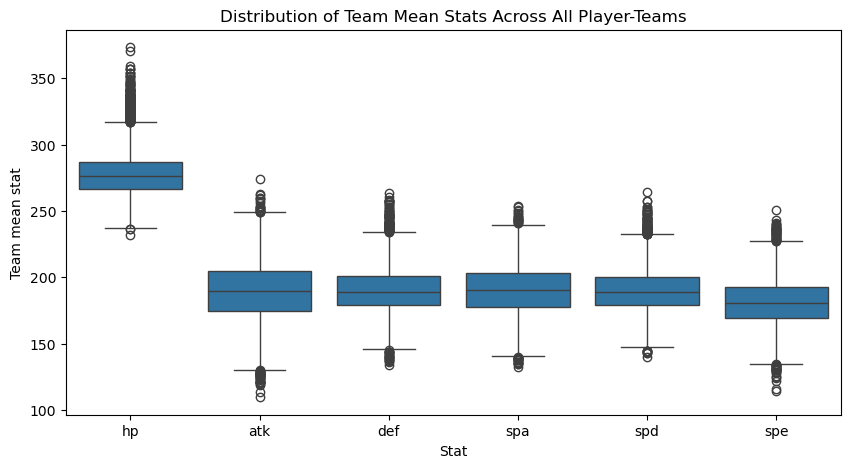

In [10]:
mean_cols = [f"{stat}_mean" for stat in STAT_NAMES]

team_stats_long = team_stats_df.melt(
    id_vars=["battle_id", "side", "won"],
    value_vars=mean_cols,
    var_name="stat",
    value_name="value",
)

team_stats_long["stat"] = team_stats_long["stat"].str.replace("_mean", "", regex=False)

plt.figure(figsize=(10, 5))
sns.boxplot(data=team_stats_long, x="stat", y="value")
plt.title("Distribution of Team Mean Stats Across All Player-Teams")
plt.xlabel("Stat")
plt.ylabel("Team mean stat")
plt.show()

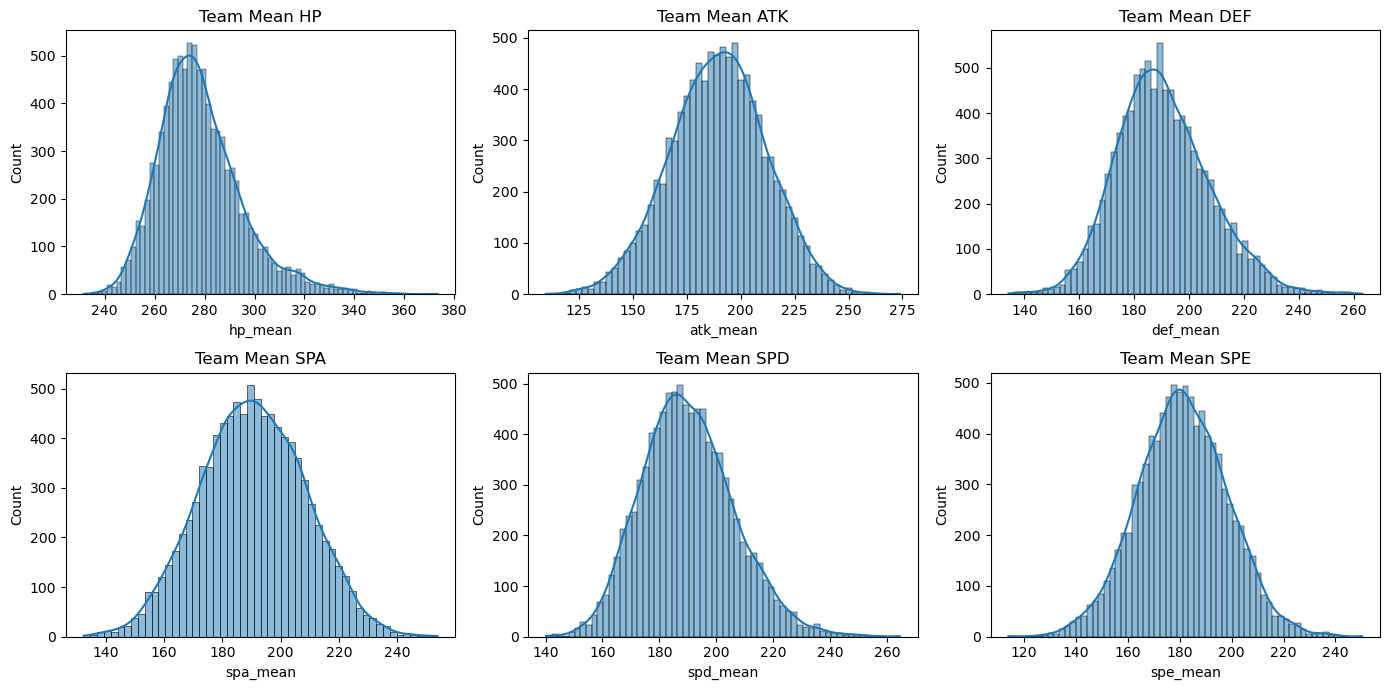

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=False)
axes = axes.ravel()

for ax, stat in zip(axes, STAT_NAMES):
    col = f"{stat}_mean"
    sns.histplot(team_stats_df[col], kde=True, ax=ax)
    ax.set_title(f"Team Mean {stat.upper()}")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

In [12]:
winner_loser_summary = (
    team_stats_df
    .groupby("won")[summary_features]
    .mean()
    .T
    .rename(columns={False: "losing_teams", True: "winning_teams"})
)

winner_loser_summary["winner_minus_loser"] = (
    winner_loser_summary["winning_teams"] -
    winner_loser_summary["losing_teams"]
)

winner_loser_summary.sort_values("winner_minus_loser", ascending=False)

won,losing_teams,winning_teams,winner_minus_loser
atk_min,115.516465,116.556899,1.040434
def_max,249.527720,250.326178,0.798458
spe_mean,180.866646,181.420210,0.553564
def_min,146.139433,146.671947,0.532514
spe_min,126.292205,126.764485,0.472280
def_mean,190.316069,190.740552,0.424482
spe_max,234.007503,234.385994,0.378491
atk_mean,189.414513,189.685112,0.270599
spd_min,146.477699,146.741767,0.264068
bst_max,1313.482493,1313.329512,-0.152980


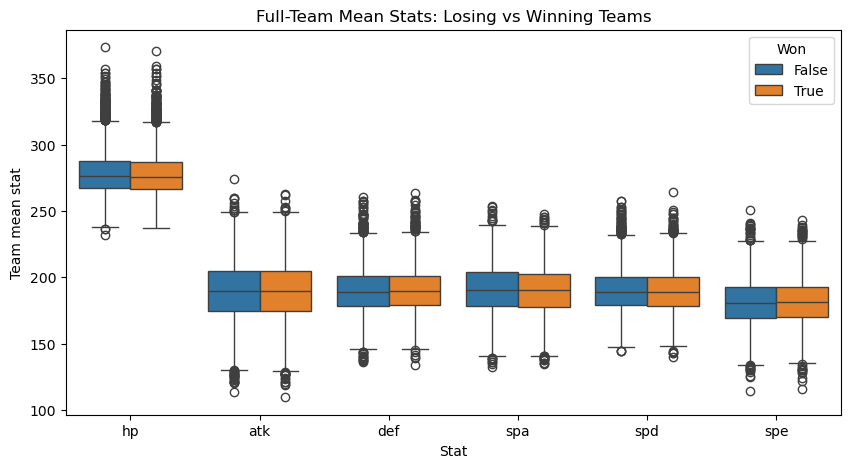

In [13]:
team_win_long = team_stats_df.melt(
    id_vars=["won"],
    value_vars=mean_cols,
    var_name="stat",
    value_name="value",
)

team_win_long["stat"] = team_win_long["stat"].str.replace("_mean", "", regex=False)

plt.figure(figsize=(10, 5))
sns.boxplot(data=team_win_long, x="stat", y="value", hue="won")
plt.title("Full-Team Mean Stats: Losing vs Winning Teams")
plt.xlabel("Stat")
plt.ylabel("Team mean stat")
plt.legend(title="Won")
plt.show()

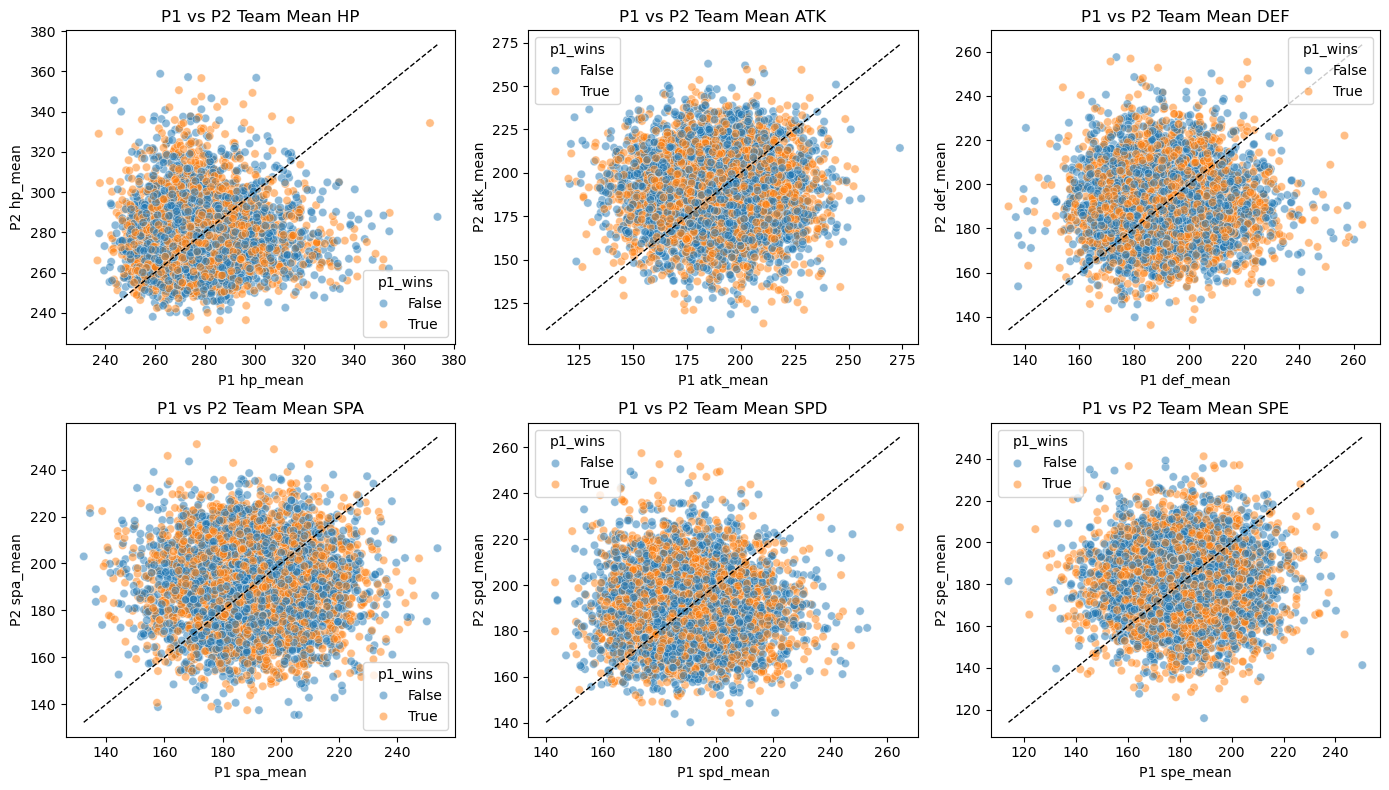

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, stat in zip(axes, STAT_NAMES):
    col = f"{stat}_mean"
    sns.scatterplot(
        data=battle_stats_df,
        x=f"p1_{col}",
        y=f"p2_{col}",
        hue="p1_wins",
        alpha=0.5,
        ax=ax,
    )

    min_val = min(battle_stats_df[f"p1_{col}"].min(), battle_stats_df[f"p2_{col}"].min())
    max_val = max(battle_stats_df[f"p1_{col}"].max(), battle_stats_df[f"p2_{col}"].max())
    ax.plot([min_val, max_val], [min_val, max_val], color="black", linestyle="--", linewidth=1)

    ax.set_title(f"P1 vs P2 Team Mean {stat.upper()}")
    ax.set_xlabel(f"P1 {col}")
    ax.set_ylabel(f"P2 {col}")

plt.tight_layout()
plt.show()

In [15]:
corrs = (
    battle_stats_df[diff_features + ["p1_wins"]]
    .corr(numeric_only=True)["p1_wins"]
    .drop("p1_wins")
    .sort_values(key=abs, ascending=False)
)

corrs

diff_hp_mean    -0.036714
diff_hp_max     -0.036595
diff_spe_mean    0.022915
diff_atk_min     0.022614
diff_def_mean    0.017609
diff_spa_min    -0.017137
diff_spa_mean   -0.016982
diff_def_min     0.016584
diff_spe_min     0.013628
diff_def_max     0.013299
diff_spa_max    -0.012037
diff_spd_min     0.011154
diff_spd_mean   -0.010391
diff_spe_max     0.009923
diff_bst_min    -0.009888
diff_atk_max    -0.009739
diff_hp_min     -0.009348
diff_atk_mean    0.008418
diff_bst_mean   -0.007007
diff_spd_max    -0.005196
diff_bst_max    -0.002792
Name: p1_wins, dtype: float64

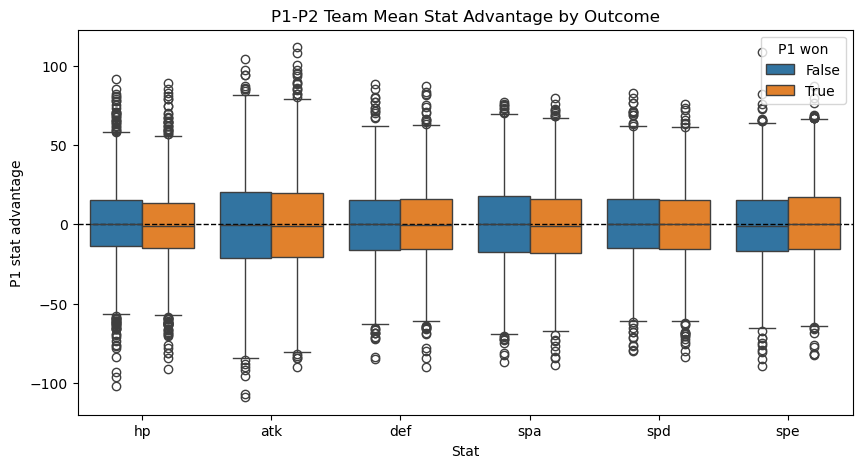

In [16]:
diff_mean_cols = [f"diff_{stat}_mean" for stat in STAT_NAMES]

diff_long = battle_stats_df.melt(
    id_vars=["p1_wins"],
    value_vars=diff_mean_cols,
    var_name="stat_diff",
    value_name="p1_minus_p2",
)

diff_long["stat_diff"] = (
    diff_long["stat_diff"]
    .str.replace("diff_", "", regex=False)
    .str.replace("_mean", "", regex=False)
)

plt.figure(figsize=(10, 5))
sns.boxplot(data=diff_long, x="stat_diff", y="p1_minus_p2", hue="p1_wins")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("P1-P2 Team Mean Stat Advantage by Outcome")
plt.xlabel("Stat")
plt.ylabel("P1 stat advantage")
plt.legend(title="P1 won")
plt.show()

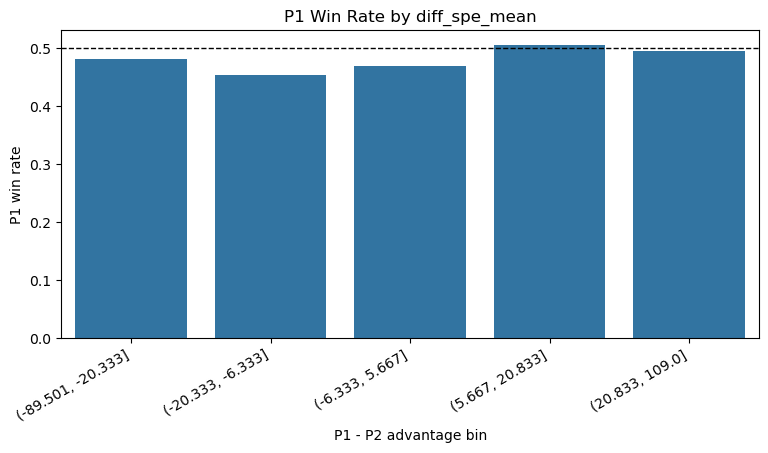

,advantage_bin,mean,count
0,"(-89.501, -20.333]",0.481289,962
1,"(-20.333, -6.333]",0.454167,960
2,"(-6.333, 5.667]",0.469792,960
3,"(5.667, 20.833]",0.506263,958
4,"(20.833, 109.0]",0.494781,958


In [17]:
def plot_win_rate_by_advantage(df, diff_col, q=5):
    temp = df[[diff_col, "p1_wins"]].dropna().copy()
    temp["advantage_bin"] = pd.qcut(temp[diff_col], q=q, duplicates="drop")

    win_rate = (
        temp
        .groupby("advantage_bin", observed=True)["p1_wins"]
        .agg(["mean", "count"])
        .reset_index()
    )

    plt.figure(figsize=(9, 4))
    sns.barplot(data=win_rate, x="advantage_bin", y="mean")
    plt.axhline(0.5, color="black", linestyle="--", linewidth=1)
    plt.title(f"P1 Win Rate by {diff_col}")
    plt.xlabel("P1 - P2 advantage bin")
    plt.ylabel("P1 win rate")
    plt.xticks(rotation=30, ha="right")
    plt.show()

    return win_rate


plot_win_rate_by_advantage(battle_stats_df, "diff_spe_mean")

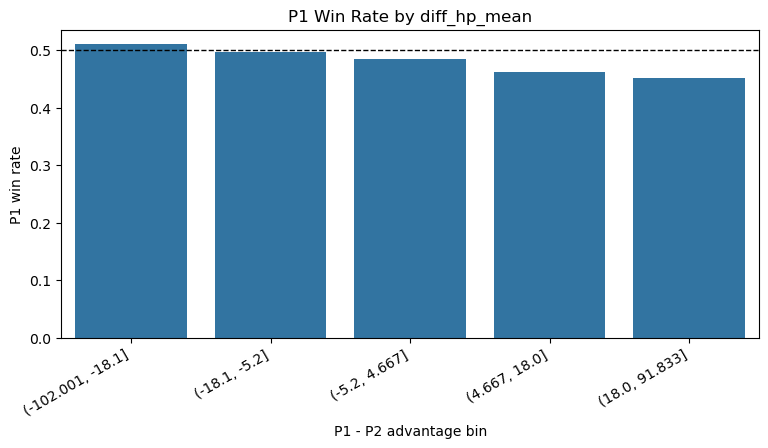

,advantage_bin,mean,count
0,"(-102.001, -18.1]",0.510417,960
1,"(-18.1, -5.2]",0.496350,959
2,"(-5.2, 4.667]",0.484375,960
3,"(4.667, 18.0]",0.462578,962
4,"(18.0, 91.833]",0.452456,957


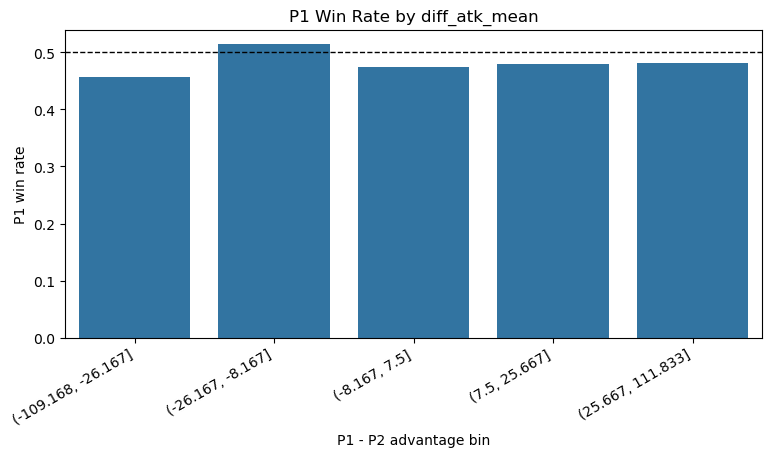

,advantage_bin,mean,count
0,"(-109.168, -26.167]",0.456432,964
1,"(-26.167, -8.167]",0.514077,959
2,"(-8.167, 7.5]",0.474453,959
3,"(7.5, 25.667]",0.479210,962
4,"(25.667, 111.833]",0.482180,954


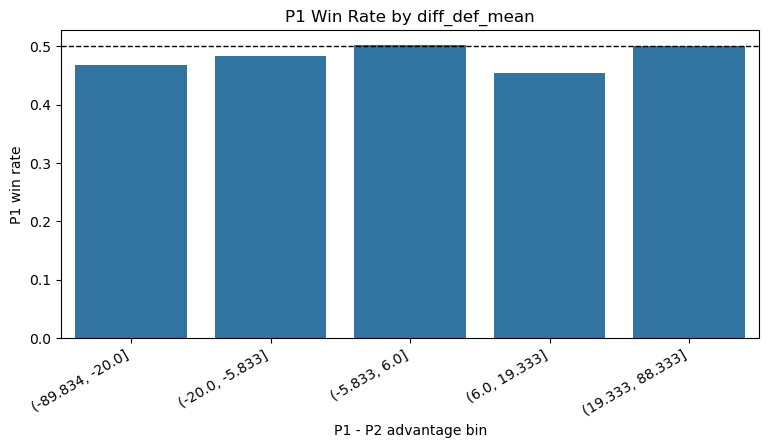

,advantage_bin,mean,count
0,"(-89.834, -20.0]",0.466874,966
1,"(-20.0, -5.833]",0.482759,957
2,"(-5.833, 6.0]",0.502601,961
3,"(6.0, 19.333]",0.453501,957
4,"(19.333, 88.333]",0.500522,957


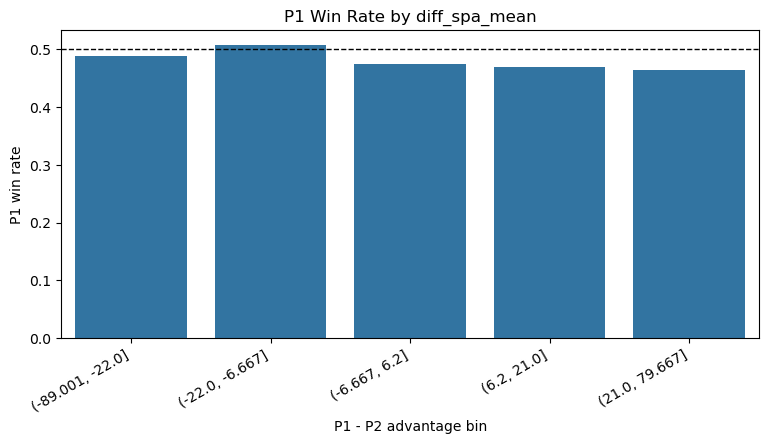

,advantage_bin,mean,count
0,"(-89.001, -22.0]",0.488132,969
1,"(-22.0, -6.667]",0.508421,950
2,"(-6.667, 6.2]",0.475000,960
3,"(6.2, 21.0]",0.470041,968
4,"(21.0, 79.667]",0.464774,951


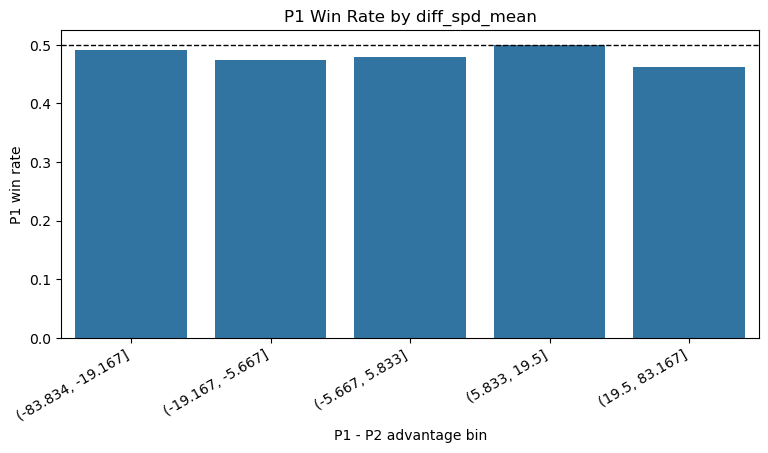

,advantage_bin,mean,count
0,"(-83.834, -19.167]",0.491155,961
1,"(-19.167, -5.667]",0.474559,963
2,"(-5.667, 5.833]",0.479079,956
3,"(5.833, 19.5]",0.500000,962
4,"(19.5, 83.167]",0.461297,956


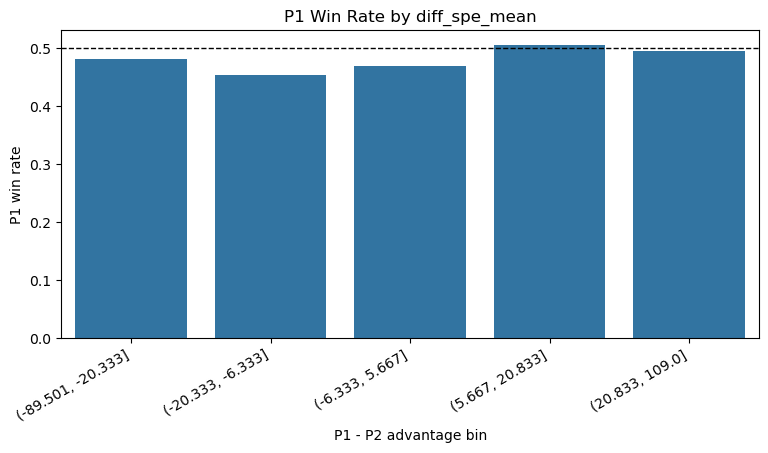

,advantage_bin,mean,count
0,"(-89.501, -20.333]",0.481289,962
1,"(-20.333, -6.333]",0.454167,960
2,"(-6.333, 5.667]",0.469792,960
3,"(5.667, 20.833]",0.506263,958
4,"(20.833, 109.0]",0.494781,958


In [18]:
for stat in STAT_NAMES:
    display(plot_win_rate_by_advantage(battle_stats_df, f"diff_{stat}_mean"))

In [19]:
pokemon_rows = []

for _, row in player_team_df.iterrows():
    for i in range(1, 7):
        pokemon_rows.append({
            "battle_id": row["battle_id"],
            "side": row["side"],
            "player": row["player"],
            "won": row["won"],
            "pokemon": row[f"mon_{i}"],
            "showed_up": row[f"mon_{i}_showed_up"],
            "hp": row[f"mon_{i}_hp"],
            "atk": row[f"mon_{i}_atk"],
            "def": row[f"mon_{i}_def"],
            "spa": row[f"mon_{i}_spa"],
            "spd": row[f"mon_{i}_spd"],
            "spe": row[f"mon_{i}_spe"],
        })

pokemon_stats_df = pd.DataFrame(pokemon_rows)

pokemon_stats_df.sample(5, random_state=42)

,battle_id,side,player,won,pokemon,showed_up,hp,atk,def,spa,spd,spe
57495,gen9randombattle-2632021860,1,who is to say,True,Diancie,True,216,211,293,211,293,129
44493,gen9randombattle-2631887796,2,bimiuchiratnhieu,True,Grimmsnarl,True,293,247,156,205,172,147
37738,gen9randombattle-2631813040,2,Green Calf,True,Tinkaton,True,274,170,173,162,219,201
273,gen9randombattle-2631369613,2,bulrug,True,Scizor,True,240,251,204,132,172,148
15599,gen9randombattle-2631531066,2,cgbynrnrnyngrnr,True,Wigglytuff,True,424,189,141,218,150,141


In [21]:
def safe_mean(values):
    if len(values) == 0:
        return np.nan
    return np.mean(values)

In [22]:
plot_rows = []

for battle_id, group in player_team_df.groupby("battle_id"):
    winner = group[group["won"] == True].iloc[0]
    loser = group[group["won"] == False].iloc[0]

    for stat in STAT_NAMES:
        winner_full_vals = [winner[f"mon_{i}_{stat}"] for i in range(1, 7)]
        loser_full_vals = [loser[f"mon_{i}_{stat}"] for i in range(1, 7)]

        winner_showed_vals = [
            winner[f"mon_{i}_{stat}"]
            for i in range(1, 7)
            if winner[f"mon_{i}_showed_up"]
        ]
        loser_showed_vals = [
            loser[f"mon_{i}_{stat}"]
            for i in range(1, 7)
            if loser[f"mon_{i}_showed_up"]
        ]

        plot_rows.append({
            "battle_id": battle_id,
            "stat": stat,
            "team_type": "full_team",
            "winner_mean": safe_mean(winner_full_vals),
            "loser_mean": safe_mean(loser_full_vals),
            "winner_n_showed": 6,
            "loser_n_showed": 6,
        })

        plot_rows.append({
            "battle_id": battle_id,
            "stat": stat,
            "team_type": "showed_up_only",
            "winner_mean": safe_mean(winner_showed_vals),
            "loser_mean": safe_mean(loser_showed_vals),
            "winner_n_showed": len(winner_showed_vals),
            "loser_n_showed": len(loser_showed_vals),
        })

winner_loser_stat_df = pd.DataFrame(plot_rows)

winner_loser_stat_df[
    winner_loser_stat_df["team_type"] == "showed_up_only"
][["winner_n_showed", "loser_n_showed"]].describe()

,winner_n_showed,loser_n_showed
count,28788.000000,28788.000000
mean,4.867236,5.449354
std,1.377539,1.116532
min,0.000000,0.000000
25%,4.000000,5.000000
50%,5.000000,6.000000
75%,6.000000,6.000000
max,6.000000,6.000000


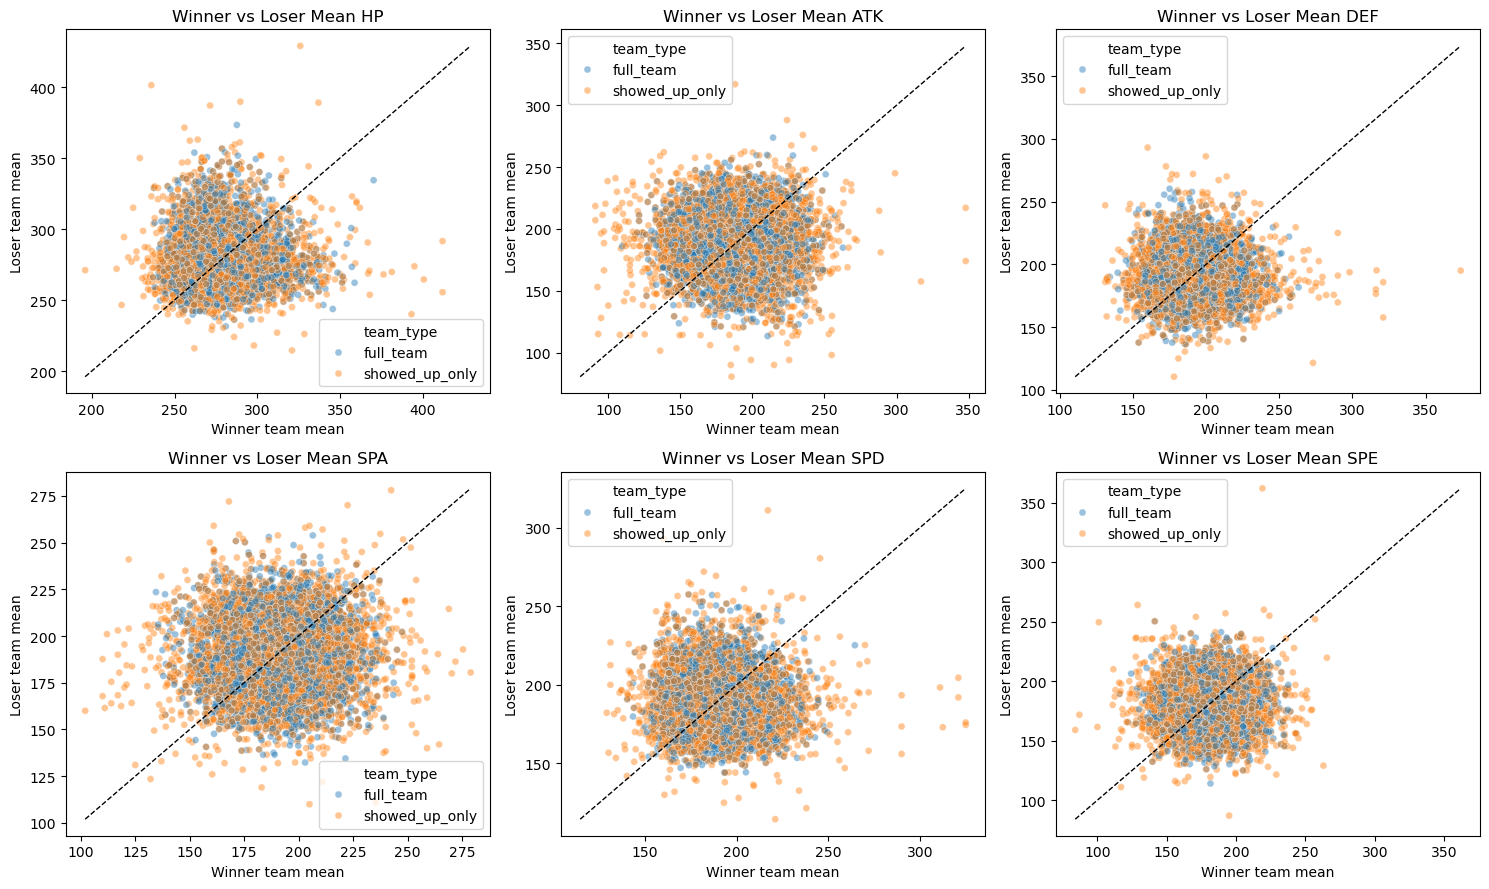

In [23]:
plot_df = winner_loser_stat_df.dropna(subset=["winner_mean", "loser_mean"])

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, stat in zip(axes, STAT_NAMES):
    temp = plot_df[plot_df["stat"] == stat]

    sns.scatterplot(
        data=temp,
        x="winner_mean",
        y="loser_mean",
        hue="team_type",
        alpha=0.45,
        s=25,
        ax=ax,
    )

    min_val = min(temp["winner_mean"].min(), temp["loser_mean"].min())
    max_val = max(temp["winner_mean"].max(), temp["loser_mean"].max())

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        color="black",
        linestyle="--",
        linewidth=1,
    )

    ax.set_title(f"Winner vs Loser Mean {stat.upper()}")
    ax.set_xlabel("Winner team mean")
    ax.set_ylabel("Loser team mean")

plt.tight_layout()
plt.show()

In [24]:
player_team_df.groupby("won")["n_appeared"].value_counts().sort_index()

won    n_appeared
False  1               77
       2              108
       3              209
       4              320
       5              547
       6             3537
True   1              175
       2              247
       3              333
       4              662
       5             1242
       6             2139
Name: count, dtype: int64

In [25]:
loser_one_showed_df = (
    player_team_df[
        (player_team_df["won"] == False)
        & (player_team_df["n_appeared"] == 1)
    ]
    .copy()
)

loser_one_showed_df["missing_team"] = loser_one_showed_df.apply(
    lambda row: sorted(set(row["team"]) - set(row["appeared_team"])),
    axis=1,
)

loser_one_showed_df[
    [
        "battle_id",
        "file_name",
        "side",
        "player",
        "n_turns",
        "duration_seconds",
        "team",
        "appeared_team",
        "missing_team",
    ]
].head(20)

,battle_id,file_name,side,player,n_turns,duration_seconds,team,appeared_team,missing_team
484,gen9randombattle-2631394646,gen9randombattle-2631394646.json,1,bellenguer2,1,0,"[Gumshoos, Hariyama, Klawf, Oranguru, Regidrag...",[Oranguru],"[Gumshoos, Hariyama, Klawf, Regidrago, Sunflora]"
550,gen9randombattle-2631399708,gen9randombattle-2631399708.json,1,pepollos,2,19,"[Alomomola, Breloom, Golem, Granbull, Persian,...",[Persian],"[Alomomola, Breloom, Golem, Granbull, Pikachu]"
684,gen9randombattle-2631408007,gen9randombattle-2631408007.json,1,taisjgzotslbxotspj,3,39,"[Arceus, Greninja, Rotom, Scovillain, Skarmory...",[Skarmory],"[Arceus, Greninja, Rotom, Scovillain, Zapdos]"
1077,gen9randombattle-2631434182,gen9randombattle-2631434182.json,2,toucann,1,0,"[Cacturne, Feraligatr, Meowstic, Sawsbuck, Sev...",[Meowstic],"[Cacturne, Feraligatr, Sawsbuck, Seviper, Tauros]"
1095,gen9randombattle-2631434982,gen9randombattle-2631434982.json,2,Pokeoke,1,0,"[Charizard, Dudunsparce, Gogoat, Heatran, Hydr...",[Heatran],"[Charizard, Dudunsparce, Gogoat, Hydreigon, Pl..."
1321,gen9randombattle-2631450070,gen9randombattle-2631450070.json,2,bellenguer2,2,24,"[Basculegion, Dewgong, Dodrio, Glaceon, Magear...",[Dodrio],"[Basculegion, Dewgong, Glaceon, Magearna, Sabl..."
1365,gen9randombattle-2631452185,gen9randombattle-2631452185.json,2,xdx42,2,38,"[Arceus, Azumarill, Forretress, Magmortar, Med...",[Magmortar],"[Arceus, Azumarill, Forretress, Medicham, Oric..."
1408,gen9randombattle-2631454141,gen9randombattle-2631454141.json,1,Fortre,1,0,"[Empoleon, Illumise, Komala, Meganium, Meowsca...",[Illumise],"[Empoleon, Komala, Meganium, Meowscarada, Suic..."
1527,gen9randombattle-2631462026,gen9randombattle-2631462026.json,2,Cygnus11235,3,25,"[Conkeldurr, Fezandipiti, Iron Hands, Latias, ...",[Latias],"[Conkeldurr, Fezandipiti, Iron Hands, Necrozma..."
1542,gen9randombattle-2631462579,gen9randombattle-2631462579.json,1,nickolassbomfim,3,15,"[Mandibuzz, Maushold, Mesprit, Primarina, Sand...",[Mandibuzz],"[Maushold, Mesprit, Primarina, Sandy Shocks, S..."


In [26]:
loser_two_showed_df = (
    player_team_df[
        (player_team_df["won"] == False)
        & (player_team_df["n_appeared"] == 2)
    ]
    .copy()
)

loser_two_showed_df["missing_team"] = loser_two_showed_df.apply(
    lambda row: sorted(set(row["team"]) - set(row["appeared_team"])),
    axis=1,
)

loser_two_showed_df[
    [
        "battle_id",
        "file_name",
        "side",
        "player",
        "n_turns",
        "duration_seconds",
        "team",
        "appeared_team",
        "missing_team",
    ]
].head(20)

,battle_id,file_name,side,player,n_turns,duration_seconds,team,appeared_team,missing_team
56,gen9randombattle-2631370821,gen9randombattle-2631370821.json,1,parathasocks,5,73,"[Hypno, Pachirisu, Salamence, Skeledirge, Suic...","[Hypno, Tentacruel]","[Pachirisu, Salamence, Skeledirge, Suicune]"
69,gen9randombattle-2631371557,gen9randombattle-2631371557.json,2,deleuzional,4,44,"[Blissey, Delibird, Dragapult, Jolteon, Poltea...","[Delibird, Dragapult]","[Blissey, Jolteon, Polteageist, Zamazenta]"
81,gen9randombattle-2631372340,gen9randombattle-2631372340.json,2,jh bruns,4,53,"[Bellibolt, Bruxish, Garganacl, Scovillain, Su...","[Suicune, Victreebel]","[Bellibolt, Bruxish, Garganacl, Scovillain]"
157,gen9randombattle-2631376249,gen9randombattle-2631376249.json,2,opik8,4,49,"[Armarouge, Girafarig, Kyogre, Rampardos, Walk...","[Girafarig, Zamazenta]","[Armarouge, Kyogre, Rampardos, Walking Wake]"
204,gen9randombattle-2631378647,gen9randombattle-2631378647.json,1,t22quent,4,81,"[Bellossom, Hydreigon, Kingdra, Scovillain, Sm...","[Scovillain, Spiritomb]","[Bellossom, Hydreigon, Kingdra, Smeargle]"
424,gen9randombattle-2631390612,gen9randombattle-2631390612.json,1,namaslaybitches,5,44,"[Alcremie, Calyrex, Drifblim, Golem, Piloswine...","[Golem, Piloswine]","[Alcremie, Calyrex, Drifblim, Whimsicott]"
515,gen9randombattle-2631396711,gen9randombattle-2631396711.json,2,Izcanas,11,290,"[Annihilape, Corviknight, Giratina, Hatterene,...","[Giratina, Maushold]","[Annihilape, Corviknight, Hatterene, Kleavor]"
731,gen9randombattle-2631411716,gen9randombattle-2631411716.json,2,PineappleCats,3,61,"[Ceruledge, Flamigo, Frosmoth, Mudsdale, Rayqu...","[Rayquaza, Sudowoodo]","[Ceruledge, Flamigo, Frosmoth, Mudsdale]"
742,gen9randombattle-2631412299,gen9randombattle-2631412299.json,1,motam8,12,125,"[Brute Bonnet, Drifblim, Lunala, Ogerpon, Oink...","[Drifblim, Suicune]","[Brute Bonnet, Lunala, Ogerpon, Oinkologne]"
976,gen9randombattle-2631427358,gen9randombattle-2631427358.json,1,bhri87 ucufu,3,34,"[Brute Bonnet, Dunsparce, Electivire, Flareon,...","[Electivire, Miraidon]","[Brute Bonnet, Dunsparce, Flareon, Glaceon]"


In [28]:
early_end_df = player_team_df[player_team_df["n_appeared"] <= 5]

early_end_df[
    ["battle_id", "file_name", "side", "player", "won", "n_turns", "duration_seconds", "n_appeared", "appeared_team"]
].head()

,battle_id,file_name,side,player,won,n_turns,duration_seconds,n_appeared,appeared_team
4,gen9randombattle-2631365384,gen9randombattle-2631365384.json,1,rgrgreger,True,32,324,5,"[Donphan, Electrode, Flareon, Primarina, Sudow..."
9,gen9randombattle-2631366401,gen9randombattle-2631366401.json,2,toonnix,True,27,383,5,"[Exeggutor, Komala, Tornadus, Victreebel, Wugt..."
14,gen9randombattle-2631366781,gen9randombattle-2631366781.json,1,Pode Isso Armald0,False,36,386,5,"[Arceus, Bombirdier, Lunala, Mimikyu, Whiscash]"
15,gen9randombattle-2631366781,gen9randombattle-2631366781.json,2,EVOL7N,True,36,386,4,"[Heracross, Iron Jugulis, Noctowl, Slaking]"
17,gen9randombattle-2631368445,gen9randombattle-2631368445.json,2,bluffmepls,True,21,158,4,"[Blissey, Pawmot, Tropius, Wugtrio]"


In [29]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

early_end_df = player_team_df[player_team_df["n_appeared"] <= 5].copy()

player_team_df.to_csv(PROCESSED_DIR / "player_team_df.csv", index=False)
early_end_df.to_csv(PROCESSED_DIR / "early_end_df.csv", index=False)

print("Saved:")
print(PROCESSED_DIR / "player_team_df.csv")
print(PROCESSED_DIR / "early_end_df.csv")
print("player_team_df shape:", player_team_df.shape)
print("early_end_df shape:", early_end_df.shape)

Saved:
E:\Erdos\Project-Pokemon\summer26-pokemon-battle-predictor\data\processed\player_team_df.csv
E:\Erdos\Project-Pokemon\summer26-pokemon-battle-predictor\data\processed\early_end_df.csv
player_team_df shape: (9596, 97)
early_end_df shape: (3920, 97)


In [30]:
player_team_df.to_pickle(PROCESSED_DIR / "player_team_df.pkl")
early_end_df.to_pickle(PROCESSED_DIR / "early_end_df.pkl")

In [31]:
full_stat_cols = [
    f"full_team_{stat}_{agg}"
    for stat in STAT_NAMES
    for agg in ["mean", "min", "max"]
]

full_team_balance_df = player_team_df[
    ["battle_id", "side", "player", "won", "n_turns", "duration_seconds"] + full_stat_cols
].copy()

full_team_balance_df.head()

,battle_id,side,player,won,n_turns,duration_seconds,full_team_hp_mean,full_team_hp_min,full_team_hp_max,full_team_atk_mean,...,full_team_def_max,full_team_spa_mean,full_team_spa_min,full_team_spa_max,full_team_spd_mean,full_team_spd_min,full_team_spd_max,full_team_spe_mean,full_team_spe_min,full_team_spe_max
0,gen9randombattle-2631360263,1,LaxMD,False,88,821,254.333333,212,290,182.833333,...,270,173.500000,95,240,188.333333,158,240,206.833333,158,270
1,gen9randombattle-2631360263,2,N.TdaRajada,True,88,821,319.666667,244,424,194.333333,...,227,168.833333,132,218,175.000000,137,228,162.333333,96,222
2,gen9randombattle-2631363920,1,kaisarian,True,31,800,259.166667,216,309,226.500000,...,247,164.500000,125,239,183.833333,147,227,168.333333,87,241
3,gen9randombattle-2631363920,2,Flamesenpai557,False,31,800,272.500000,196,389,226.166667,...,216,172.000000,117,222,159.500000,134,206,198.500000,117,255
4,gen9randombattle-2631365384,1,rgrgreger,True,32,324,267.500000,246,288,187.666667,...,270,191.000000,110,257,209.000000,149,251,181.166667,110,311


In [37]:
battle_balance_rows = []

for battle_id, group in full_team_balance_df.groupby("battle_id"):
    if len(group) != 2:
        continue

    p1 = group[group["side"] == 1].iloc[0]
    p2 = group[group["side"] == 2].iloc[0]

    row = {"battle_id": battle_id}

    for stat in STAT_NAMES:
        for agg in ["mean", "min", "max"]:
            col = f"full_team_{stat}_{agg}"
            row[f"abs_diff_{stat}_{agg}"] = abs(p1[col] - p2[col])
            row[f"signed_diff_{stat}_{agg}"] = p1[col] - p2[col]

    battle_balance_rows.append(row)

battle_team_balance_df = pd.DataFrame(battle_balance_rows)

battle_team_balance_df.head()

,battle_id,abs_diff_hp_mean,signed_diff_hp_mean,abs_diff_hp_min,signed_diff_hp_min,abs_diff_hp_max,signed_diff_hp_max,abs_diff_atk_mean,signed_diff_atk_mean,abs_diff_atk_min,...,abs_diff_spd_min,signed_diff_spd_min,abs_diff_spd_max,signed_diff_spd_max,abs_diff_spe_mean,signed_diff_spe_mean,abs_diff_spe_min,signed_diff_spe_min,abs_diff_spe_max,signed_diff_spe_max
0,gen9randombattle-2631360263,65.333333,-65.333333,32,-32,134,-134,11.500000,-11.500000,11,...,21,21,12,12,44.500000,44.500000,62,62,48,48
1,gen9randombattle-2631363920,13.333333,-13.333333,20,20,80,-80,0.333333,0.333333,24,...,13,13,21,21,30.166667,-30.166667,30,-30,14,-14
2,gen9randombattle-2631365384,12.500000,-12.500000,1,-1,23,-23,13.666667,13.666667,25,...,3,-3,16,-16,2.833333,-2.833333,7,7,60,60
3,gen9randombattle-2631366366,32.166667,32.166667,14,14,52,52,38.000000,38.000000,48,...,28,28,34,-34,20.166667,20.166667,11,-11,31,31
4,gen9randombattle-2631366401,1.000000,-1.000000,34,34,14,-14,62.000000,-62.000000,119,...,38,-38,41,41,20.333333,20.333333,68,68,11,-11


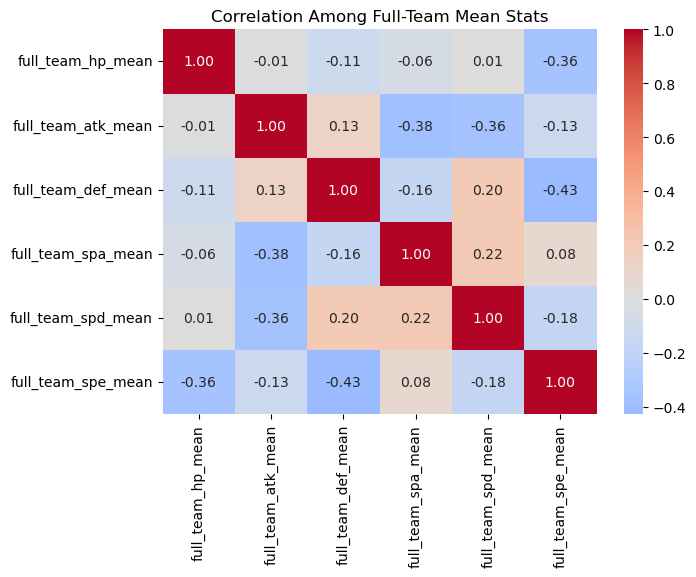

In [39]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    full_team_balance_df[mean_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
)
plt.title("Correlation Among Full-Team Mean Stats")
plt.show()

## Speed Analysis

The following part investigates the correlation between pokemon speed with battle outcome, as speed is one of the important features in pokemon battle.

In [40]:
# Build winner/loser speed rows using full-team speed stats only

speed_rows = []

for battle_id, group in player_team_df.groupby("battle_id"):
    if len(group) != 2:
        continue

    winner = group[group["won"] == True].iloc[0]
    loser = group[group["won"] == False].iloc[0]

    winner_speeds = sorted(
        [winner[f"mon_{i}_spe"] for i in range(1, 7)],
        reverse=True,
    )
    loser_speeds = sorted(
        [loser[f"mon_{i}_spe"] for i in range(1, 7)],
        reverse=True,
    )

    row = {
        "battle_id": battle_id,

        "winner_spe_min": min(winner_speeds),
        "winner_spe_mean": np.mean(winner_speeds),
        "winner_spe_max": max(winner_speeds),

        "loser_spe_min": min(loser_speeds),
        "loser_spe_mean": np.mean(loser_speeds),
        "loser_spe_max": max(loser_speeds),

        "diff_spe_min": min(winner_speeds) - min(loser_speeds),
        "diff_spe_mean": np.mean(winner_speeds) - np.mean(loser_speeds),
        "diff_spe_max": max(winner_speeds) - max(loser_speeds),
    }

    for rank in range(1, 7):
        row[f"winner_spe_rank_{rank}"] = winner_speeds[rank - 1]
        row[f"loser_spe_rank_{rank}"] = loser_speeds[rank - 1]
        row[f"diff_spe_rank_{rank}"] = winner_speeds[rank - 1] - loser_speeds[rank - 1]

    speed_rows.append(row)

speed_eda_df = pd.DataFrame(speed_rows)

speed_eda_df.head()

,battle_id,winner_spe_min,winner_spe_mean,winner_spe_max,loser_spe_min,loser_spe_mean,loser_spe_max,diff_spe_min,diff_spe_mean,diff_spe_max,...,diff_spe_rank_3,winner_spe_rank_4,loser_spe_rank_4,diff_spe_rank_4,winner_spe_rank_5,loser_spe_rank_5,diff_spe_rank_5,winner_spe_rank_6,loser_spe_rank_6,diff_spe_rank_6
0,gen9randombattle-2631360263,96,162.333333,222,158,206.833333,270,-62,-44.500000,-48,...,-24,141,204,-63,132,177,-45,96,158,-62
1,gen9randombattle-2631363920,87,168.333333,241,117,198.500000,255,-30,-30.166667,-14,...,-29,164,206,-42,134,164,-30,87,117,-30
2,gen9randombattle-2631365384,110,181.166667,311,103,184.000000,251,7,-2.833333,60,...,-40,147,203,-56,132,124,8,110,103,7
3,gen9randombattle-2631366366,117,152.333333,210,106,172.500000,241,11,-20.166667,-31,...,-38,128,170,-42,121,125,-4,117,106,11
4,gen9randombattle-2631366401,77,174.833333,270,145,195.166667,259,-68,-20.333333,11,...,-26,165,189,-24,131,151,-20,77,145,-68


In [41]:
# Summary table: winner vs loser speed min/mean/max

speed_summary_rows = []

for feature in ["spe_min", "spe_mean", "spe_max"]:
    winner_col = f"winner_{feature}"
    loser_col = f"loser_{feature}"
    diff_col = f"diff_{feature}"

    speed_summary_rows.append({
        "feature": feature,
        "winner_mean": speed_eda_df[winner_col].mean(),
        "loser_mean": speed_eda_df[loser_col].mean(),
        "winner_minus_loser_mean": speed_eda_df[diff_col].mean(),
        "winner_minus_loser_median": speed_eda_df[diff_col].median(),
        "winner_higher_pct": (speed_eda_df[diff_col] > 0).mean(),
        "tie_pct": (speed_eda_df[diff_col] == 0).mean(),
        "loser_higher_pct": (speed_eda_df[diff_col] < 0).mean(),
    })

speed_min_mean_max_summary = pd.DataFrame(speed_summary_rows)

speed_min_mean_max_summary

,feature,winner_mean,loser_mean,winner_minus_loser_mean,winner_minus_loser_median,winner_higher_pct,tie_pct,loser_higher_pct
0,spe_min,126.764485,126.292205,0.472280,0.000000,0.497082,0.017924,0.484994
1,spe_mean,181.420210,180.866646,0.553564,0.666667,0.509587,0.003335,0.487078
2,spe_max,234.385994,234.007503,0.378491,0.000000,0.496040,0.020008,0.483952


In [42]:
# Summary table: ranked speed comparison
# Rank 1 = fastest Pokemon, rank 6 = slowest Pokemon

speed_rank_summary_rows = []

for rank in range(1, 7):
    diff_col = f"diff_spe_rank_{rank}"

    speed_rank_summary_rows.append({
        "speed_rank": rank,
        "winner_mean": speed_eda_df[f"winner_spe_rank_{rank}"].mean(),
        "loser_mean": speed_eda_df[f"loser_spe_rank_{rank}"].mean(),
        "winner_minus_loser_mean": speed_eda_df[diff_col].mean(),
        "winner_minus_loser_median": speed_eda_df[diff_col].median(),
        "winner_higher_pct": (speed_eda_df[diff_col] > 0).mean(),
        "tie_pct": (speed_eda_df[diff_col] == 0).mean(),
        "loser_higher_pct": (speed_eda_df[diff_col] < 0).mean(),
    })

speed_rank_summary = pd.DataFrame(speed_rank_summary_rows)

speed_rank_summary

,speed_rank,winner_mean,loser_mean,winner_minus_loser_mean,winner_minus_loser_median,winner_higher_pct,tie_pct,loser_higher_pct
0,1,234.385994,234.007503,0.378491,0.0,0.496040,0.020008,0.483952
1,2,209.196123,208.871405,0.324719,0.0,0.493539,0.017507,0.488954
2,3,191.484368,190.437266,1.047103,1.0,0.514381,0.016048,0.469571
3,4,173.395373,172.771988,0.623385,1.0,0.502918,0.017924,0.479158
4,5,153.294915,152.819508,0.475406,0.0,0.499375,0.015423,0.485202
5,6,126.764485,126.292205,0.472280,0.0,0.497082,0.017924,0.484994


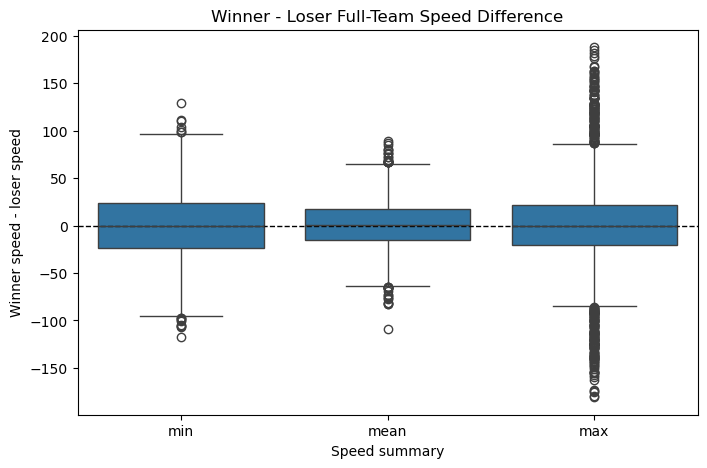

In [43]:
# Plot: winner vs loser speed min/mean/max distributions

speed_min_mean_max_long = speed_eda_df.melt(
    value_vars=[
        "diff_spe_min",
        "diff_spe_mean",
        "diff_spe_max",
    ],
    var_name="speed_feature",
    value_name="winner_minus_loser",
)

speed_min_mean_max_long["speed_feature"] = (
    speed_min_mean_max_long["speed_feature"]
    .str.replace("diff_spe_", "", regex=False)
)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=speed_min_mean_max_long,
    x="speed_feature",
    y="winner_minus_loser",
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Winner - Loser Full-Team Speed Difference")
plt.xlabel("Speed summary")
plt.ylabel("Winner speed - loser speed")
plt.show()

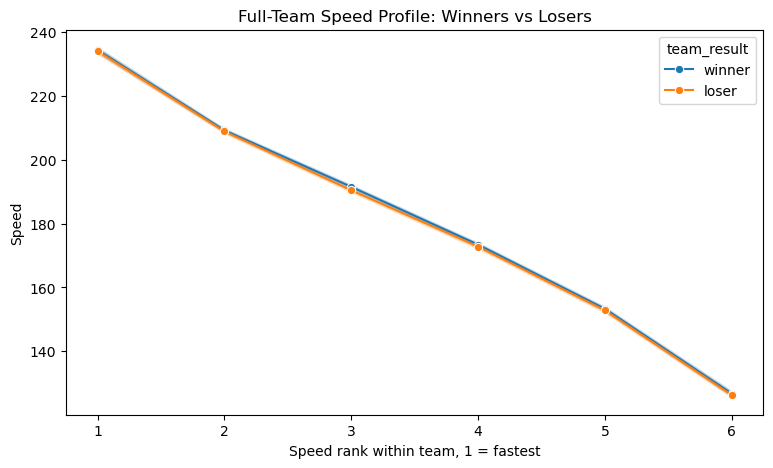

In [44]:
# Plot: ranked speed profile for winners vs losers

speed_rank_long_rows = []

for _, row in speed_eda_df.iterrows():
    for rank in range(1, 7):
        speed_rank_long_rows.append({
            "battle_id": row["battle_id"],
            "rank": rank,
            "team_result": "winner",
            "speed": row[f"winner_spe_rank_{rank}"],
        })
        speed_rank_long_rows.append({
            "battle_id": row["battle_id"],
            "rank": rank,
            "team_result": "loser",
            "speed": row[f"loser_spe_rank_{rank}"],
        })

speed_rank_long = pd.DataFrame(speed_rank_long_rows)

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=speed_rank_long,
    x="rank",
    y="speed",
    hue="team_result",
    marker="o",
    errorbar=("ci", 95),
)
plt.title("Full-Team Speed Profile: Winners vs Losers")
plt.xlabel("Speed rank within team, 1 = fastest")
plt.ylabel("Speed")
plt.xticks(range(1, 7))
plt.show()

The weak signal from raw stat features may reflect Random Battle balancing. Since Pokemon levels and generated stats are adjusted, raw team stat differences are compressed. As a result, simple summaries like team mean Speed, max Speed, or average bulk may not capture enough matchup-specific information to predict the winner.

## Derived Stats


In [45]:
derived_defs = {
    "physical_bulk": lambda m: m["hp"] + m["def"],
    "special_bulk": lambda m: m["hp"] + m["spd"],
    "mixed_bulk": lambda m: m["hp"] + m["def"] + m["spd"],
    "best_attack": lambda m: max(m["atk"], m["spa"]),
    "offensive_pressure": lambda m: max(m["atk"], m["spa"]) + m["spe"],
}

derived_rows = []

for _, row in player_team_df.iterrows():
    out = {
        "battle_id": row["battle_id"],
        "side": row["side"],
        "player": row["player"],
        "won": row["won"],
        "n_turns": row["n_turns"],
        "duration_seconds": row["duration_seconds"],
        "n_appeared": row["n_appeared"],
    }

    mons = [
        {
            "hp": row[f"mon_{i}_hp"],
            "atk": row[f"mon_{i}_atk"],
            "def": row[f"mon_{i}_def"],
            "spa": row[f"mon_{i}_spa"],
            "spd": row[f"mon_{i}_spd"],
            "spe": row[f"mon_{i}_spe"],
        }
        for i in range(1, 7)
    ]

    for feature, func in derived_defs.items():
        vals = [func(mon) for mon in mons]
        out[f"{feature}_mean"] = np.mean(vals)
        out[f"{feature}_min"] = np.min(vals)
        out[f"{feature}_max"] = np.max(vals)

    derived_rows.append(out)

derived_stats_eda_df = pd.DataFrame(derived_rows)

derived_stats_eda_df.head()

,battle_id,side,player,won,n_turns,duration_seconds,n_appeared,physical_bulk_mean,physical_bulk_min,physical_bulk_max,...,special_bulk_max,mixed_bulk_mean,mixed_bulk_min,mixed_bulk_max,best_attack_mean,best_attack_min,best_attack_max,offensive_pressure_mean,offensive_pressure_min,offensive_pressure_max
0,gen9randombattle-2631360263,1,LaxMD,False,88,821,6,443.500000,355,505,...,512,631.833333,534,680,222.500000,174,240,429.333333,332,504
1,gen9randombattle-2631360263,2,N.TdaRajada,True,88,821,6,495.166667,391,565,...,625,670.166667,538,779,212.000000,142,255,374.333333,324,477
2,gen9randombattle-2631363920,1,kaisarian,True,31,800,6,453.500000,388,514,...,514,637.333333,562,732,231.833333,188,263,400.166667,326,457
3,gen9randombattle-2631363920,2,Flamesenpai557,False,31,800,6,454.333333,345,605,...,546,613.833333,511,762,241.833333,206,317,440.333333,344,533
4,gen9randombattle-2631365384,1,rgrgreger,True,32,324,5,469.166667,418,554,...,512,678.166667,607,730,240.166667,189,285,421.333333,351,500


In [46]:
derived_features = list(derived_defs.keys())
derived_cols = [
    f"{feature}_{agg}"
    for feature in derived_features
    for agg in ["mean", "min", "max"]
]

derived_summary = (
    derived_stats_eda_df
    .groupby("won")[derived_cols]
    .mean()
    .T
    .rename(columns={False: "losing_teams", True: "winning_teams"})
)

derived_summary["winner_minus_loser"] = (
    derived_summary["winning_teams"] - derived_summary["losing_teams"]
)

derived_summary.sort_values("winner_minus_loser", ascending=False)

won,losing_teams,winning_teams,winner_minus_loser
offensive_pressure_min,336.521676,337.067528,0.545852
offensive_pressure_mean,406.328540,406.813777,0.485237
offensive_pressure_max,467.868070,468.319925,0.451855
best_attack_min,180.636724,180.708420,0.071697
best_attack_mean,225.461894,225.393567,-0.068327
mixed_bulk_min,570.112338,570.001042,-0.111296
physical_bulk_min,402.571071,402.214048,-0.357024
special_bulk_min,404.602334,404.214464,-0.387870
physical_bulk_mean,468.977074,468.538419,-0.438655
best_attack_max,265.743226,265.297624,-0.445602


In [47]:
winner_loser_rows = []

for battle_id, group in derived_stats_eda_df.groupby("battle_id"):
    if len(group) != 2:
        continue

    winner = group[group["won"]].iloc[0]
    loser = group[~group["won"]].iloc[0]

    out = {"battle_id": battle_id}

    for col in derived_cols:
        out[f"diff_{col}"] = winner[col] - loser[col]

    winner_loser_rows.append(out)

derived_diff_df = pd.DataFrame(winner_loser_rows)

derived_diff_df.head()

,battle_id,diff_physical_bulk_mean,diff_physical_bulk_min,diff_physical_bulk_max,diff_special_bulk_mean,diff_special_bulk_min,diff_special_bulk_max,diff_mixed_bulk_mean,diff_mixed_bulk_min,diff_mixed_bulk_max,diff_best_attack_mean,diff_best_attack_min,diff_best_attack_max,diff_offensive_pressure_mean,diff_offensive_pressure_min,diff_offensive_pressure_max
0,gen9randombattle-2631360263,51.666667,36,60,52.000000,-3,113,38.333333,4,99,-10.500000,-32,15,-55.000000,-8,-27
1,gen9randombattle-2631363920,-0.833333,43,-91,11.000000,20,-32,23.500000,51,-30,-10.000000,-18,-54,-40.166667,-18,-76
2,gen9randombattle-2631365384,-10.333333,9,2,-4.166667,18,-42,-2.000000,9,-44,35.833333,52,44,33.000000,22,44
3,gen9randombattle-2631366366,-27.666667,-41,-19,-28.166667,-44,-25,-23.666667,-50,-54,1.000000,51,-47,-19.166667,-12,-82
4,gen9randombattle-2631366401,6.333333,-61,49,-1.666667,-23,-72,3.666667,-53,21,24.833333,19,35,4.500000,-30,13


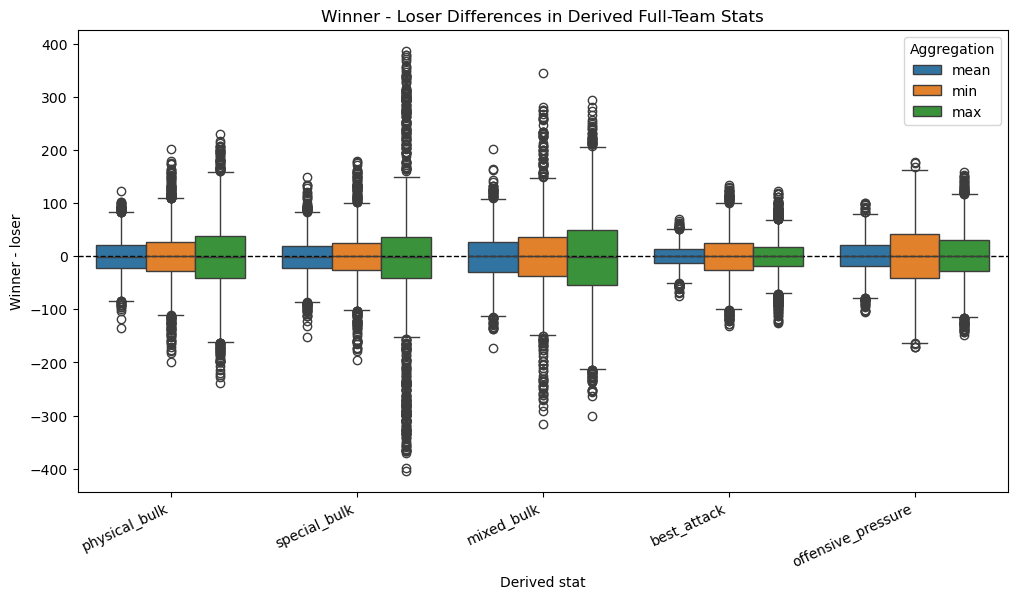

In [48]:
derived_diff_long = derived_diff_df.melt(
    id_vars=["battle_id"],
    value_vars=[f"diff_{col}" for col in derived_cols],
    var_name="feature",
    value_name="winner_minus_loser",
)

derived_diff_long["feature"] = derived_diff_long["feature"].str.replace("diff_", "", regex=False)

derived_diff_long[["derived_stat", "aggregation"]] = derived_diff_long["feature"].str.extract(
    r"(.+)_(mean|min|max)"
)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=derived_diff_long,
    x="derived_stat",
    y="winner_minus_loser",
    hue="aggregation",
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Winner - Loser Differences in Derived Full-Team Stats")
plt.xlabel("Derived stat")
plt.ylabel("Winner - loser")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Aggregation")
plt.show()

In [49]:
derived_diff_summary = (
    derived_diff_long
    .groupby(["derived_stat", "aggregation"])["winner_minus_loser"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        winner_higher_pct=lambda s: (s > 0).mean(),
        tie_pct=lambda s: (s == 0).mean(),
        loser_higher_pct=lambda s: (s < 0).mean(),
    )
    .reset_index()
    .sort_values("mean", ascending=False)
)

derived_diff_summary

,derived_stat,aggregation,mean,median,std,winner_higher_pct,tie_pct,loser_higher_pct
8,offensive_pressure,min,0.545852,1.000000,59.431683,0.501459,0.013339,0.485202
7,offensive_pressure,mean,0.485237,0.666667,29.569080,0.507712,0.002709,0.489579
6,offensive_pressure,max,0.451855,1.000000,45.244690,0.501667,0.016674,0.481659
2,best_attack,min,0.071697,1.000000,39.436635,0.500834,0.018966,0.480200
1,best_attack,mean,-0.068327,0.333333,19.275961,0.505627,0.003752,0.490621
5,mixed_bulk,min,-0.111296,0.000000,62.692377,0.491455,0.012922,0.495623
11,physical_bulk,min,-0.357024,0.000000,44.688726,0.487495,0.017090,0.495415
14,special_bulk,min,-0.387870,0.000000,42.557227,0.486453,0.019383,0.494164
10,physical_bulk,mean,-0.438655,-1.166667,31.567866,0.486870,0.001459,0.511672
0,best_attack,max,-0.445602,0.000000,30.592452,0.479366,0.030221,0.490413
